In [2]:
import xarray as xr

url = "https://a3s.fi/swift/v1/AUTH_0914d8aff9684df589041a759b549fc2/PythonGIS/elevation/kilimanjaro/ASTGTMV003_S03E036_dem.tif"
data = xr.open_dataset(url, engine="rasterio")
data

<xarray.Dataset> Size: 52MB
Dimensions:      (band: 1, x: 3601, y: 3601)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 52MB ...

In [3]:
data = data.squeeze("band", drop=True)
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (y, x) float32 52MB ...

In [4]:
data = data.rename({"band_data": "elevation"})
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB 36.0 36.0 36.0 36.0 ... 37.0 37.0 37.0 37.0
  * y            (y) float64 29kB -2.0 -2.0 -2.001 -2.001 ... -2.999 -3.0 -3.0
    spatial_ref  int64 8B ...
Data variables:
    elevation    (y, x) float32 52MB ...

In [5]:
data["elevation"].max()

<xarray.DataArray 'elevation' ()> Size: 8B
array(2943.)
Coordinates:
    spatial_ref  int64 8B ...

In [10]:
data["elevation"].min().item()

568.0

In [12]:
print(data.rio.shape)

(3601, 3601)


In [15]:
data.rio.resolution()

(0.000277777777777778, -0.000277777777777778)

In [6]:
min_elevation = data['elevation'].min().item()
data['relative_height'] = data['elevation'] - min_elevation
data
min_elevation

568.0

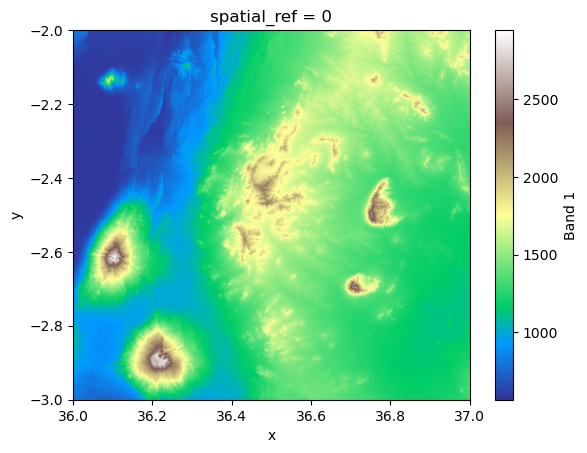

In [7]:
data["elevation"].plot(cmap="terrain")

In [2]:
import xarray as xr
import os
import rioxarray as rxr
from rioxarray.merge import merge_datasets

# S3 bucket containing the data
bucket = "https://a3s.fi/swift/v1/AUTH_0914d8aff9684df589041a759b549fc2/PythonGIS"

# Generate urls for the elevation files
urls = [
    os.path.join(bucket, "elevation/kilimanjaro/ASTGTMV003_S03E036_dem.tif"),
    os.path.join(bucket, "elevation/kilimanjaro/ASTGTMV003_S03E037_dem.tif")
]

# Read the files
datasets = [
    xr.open_dataset(url, engine="rasterio").squeeze("band", drop=True) for url in urls
]


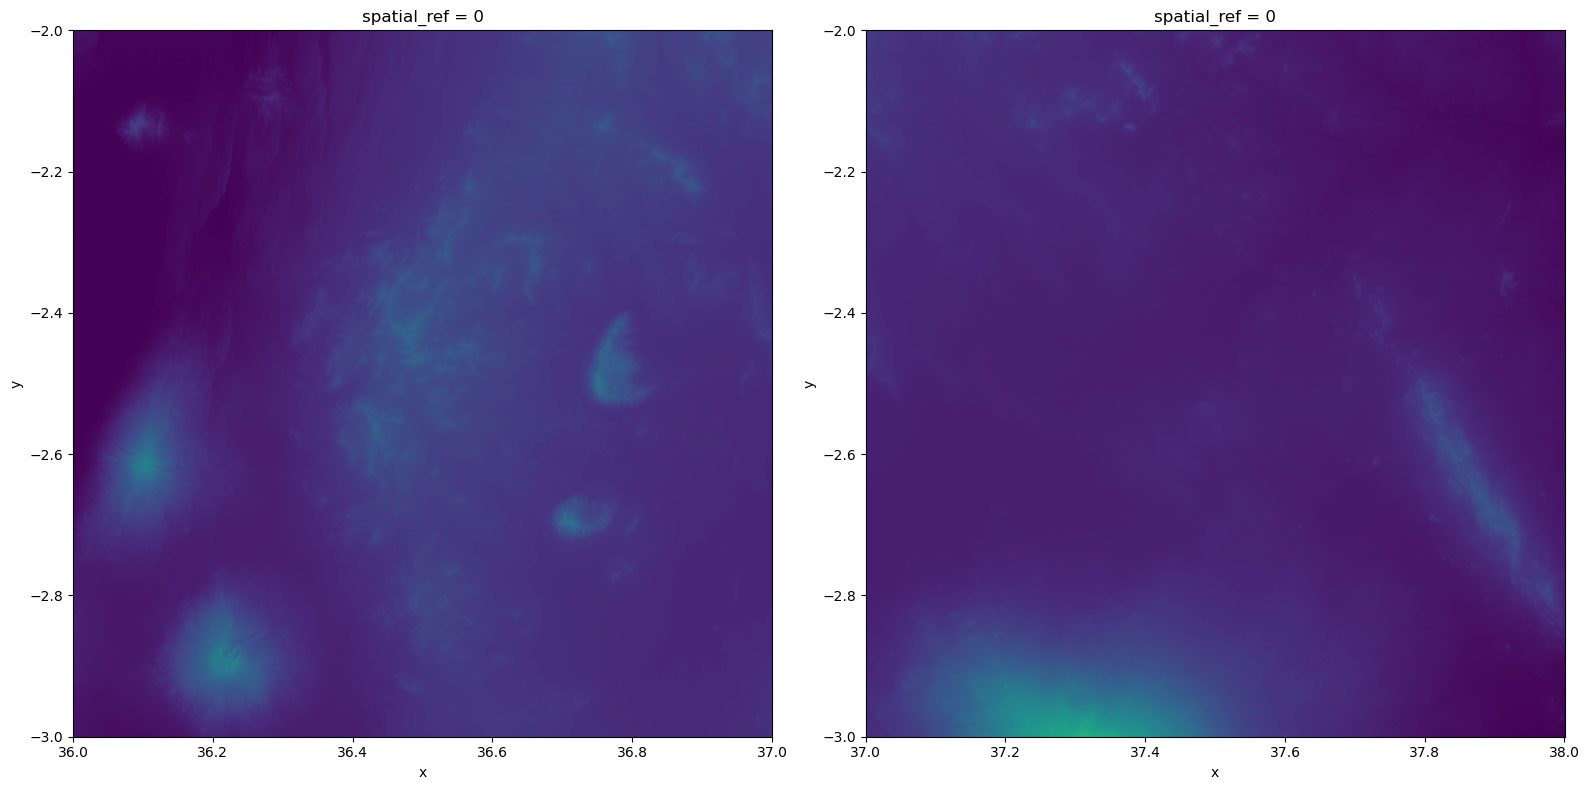

In [3]:
import matplotlib.pyplot as plt

# Create a 1-row, 2-column subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the datasets side by side
datasets[0]["band_data"].plot(ax=axes[0], vmax=5900, add_colorbar=False)
datasets[1]["band_data"].plot(ax=axes[1], vmax=5900, add_colorbar=False)

plt.tight_layout()  # Optional, to avoid overlap
plt.show()

In [4]:
mosaic = merge_datasets(datasets)

/opt/conda/envs/GeospatialPyContainer/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3577: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)


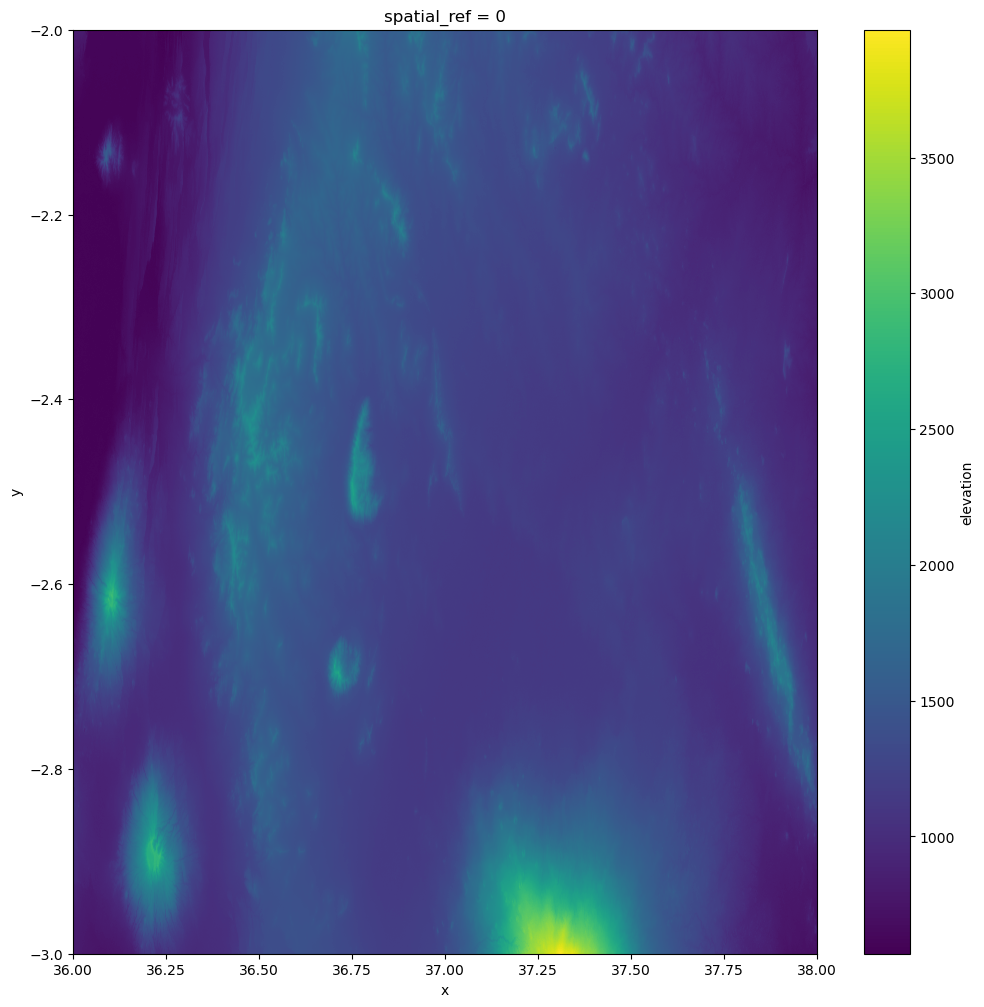

In [5]:
mosaic = mosaic.rename({"band_data": "elevation"})
mosaic["elevation"].plot(figsize=(12,12))

In [1]:
import geopandas as gpd
from shapely.geometry import box

# Bounding box coordinates
minx = 37.1
miny = -3.3B
maxx = 37.6
maxy = -2.85

# Create a GeoDataFrame that will be used to clip the raster
geom = box(minx, miny, maxx, maxy)
clipping_gdf = gpd.GeoDataFrame({"geometry": [geom]}, index=[0], crs="epsg:4326")

# Explore the extent on a map
clipping_gdf.explore()

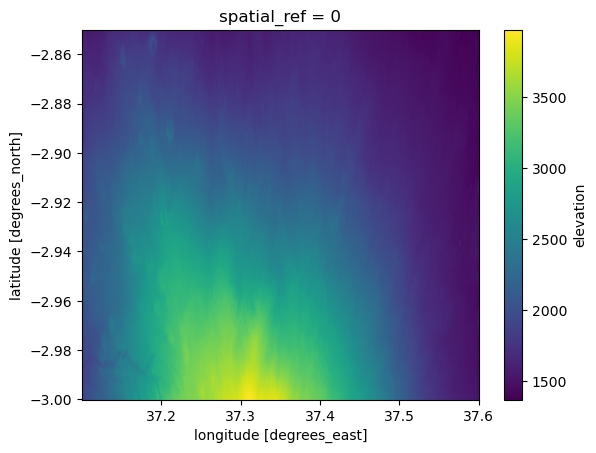

In [6]:
# Clip the Mosaic with GeoDataFrame and specify CRS
kilimanjaro = mosaic.rio.clip(clipping_gdf.geometry, crs=mosaic.elevation.rio.crs)
kilimanjaro["elevation"].plot()

In [8]:
kilimanjaro
# Save file to GeoTIFF
kilimanjaro.rio.to_raster("data/kilimanjaro.tif", compress="LZMA", tiled=True)